https://stackoverflow.com/questions/74141355/dimensionality-reduction-autoencoder-pytorch

#### Imports

In [1]:
import time
import copy
from pathlib import Path
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor

from tqdm import tqdm
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import pickle

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

Current device: cuda


In [2]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [4]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))
X_tr, X_val, Y_tr, Y_val = train_test_split(X, Y_resh, test_size=0.2, random_state=42)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("wavelengths shape:", wavelengths.shape)
print()
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("Y_tr shape:", Y_tr.shape)
print("Y_val shape:", Y_val.shape)

X shape: (500, 9)
Y shape: (500, 25230)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (100, 9)
Y_tr shape: (400, 6, 4205)
Y_val shape: (100, 6, 4205)


#### Dimensionality Reduction

PCA and Kernel PCA.

In [16]:
def apply_pca(Y_tr, Y_val, n_components=10, kernel=False):
    """
    Apply PCA or KernelPCA to each function separately, retaining n_components components.
    - Y_tr: training outputs of shape (n_samples, n_functions, n_wavelengths)
    - Y_val: validation outputs of shape (n_samples, n_functions, n_wavelengths)
    - n_components: number of PCA components to retain
    - kernel: if True, use KernelPCA with RBF kernel; if False, use regular PCA
    - returns: list of PCA objects, list of transformed training outputs, list of transformed validation outputs
    """

    print(f"========== Applying {'KernelPCA' if kernel else 'PCA'} with n_components={n_components} to each function separately... ==========")
    pca_list = []
    Y_tr_pca_list = []
    Y_val_pca_list = []

    for i in range(Y_tr.shape[1]):
        if kernel:
            pca = KernelPCA(n_components=n_components, kernel=kernel, gamma=1e-2, fit_inverse_transform=True, alpha=0.1)
        else:
            pca = PCA(n_components=n_components)
        
        Y_tr_i = Y_tr[:, i, :] # shape of function: (n_samples, n_wavelengths)
        Y_val_i = Y_val[:, i, :]
        
        Y_tr_pca = pca.fit_transform(Y_tr_i)     # fit training here
        print(Y_tr_pca.shape)
        Y_val_pca = pca.transform(Y_val_i)       # just transform validation to avoid information leak
        
        pca_list.append(pca)
        Y_tr_pca_list.append(Y_tr_pca)
        Y_val_pca_list.append(Y_val_pca)

    # print amount of explained variance and number of components for each function
    total_explained_variance = 0

    if not kernel:
        print("  Regular PCA used, displaying results:")
        for i, pca in enumerate(pca_list):
            explained_variance = pca.explained_variance_ratio_.sum()
            total_explained_variance += explained_variance
            print(f"  Function {i+1}: Explained variance = {explained_variance:.4f}")
            print(f"  Number of components retained: {pca.n_components_}")
            print()

        print(f"  Total explained variance = {total_explained_variance:.4f}")

    print("========== PCA application completed. ==========\n")

    return pca_list, Y_tr_pca_list, Y_val_pca_list

#### Scaling

In [ ]:
def scale_data(x_tr, x_val, y_tr_red_list, scale_type="standard"):
    """
    Scale the data using either standard scaling or min-max scaling
    - inputs: training inputs, validation inputs, list of PCA-transformed training outputs, scaling type
    - outputs: scaled training inputs, scaled validation inputs, list of scaled PCA-transformed training outputs, list of scalers used for each output function
    """
    print(f"========== Scaling data using {scale_type} scaling... ==========")
    scaler = StandardScaler() if scale_type == "standard" else MinMaxScaler()

    # standard scaling
    x_scaler = scaler.fit(x_tr)
    X_tr_scaled = x_scaler.transform(x_tr)
    X_val_scaled = x_scaler.transform(x_val)

    y_scalers = []
    Y_tr_reduced_scaled_list = []
    for i in range(globals.N_FUNCTIONS):
        scaler = StandardScaler() if scale_type == "standard" else MinMaxScaler()
        Y_scaled = scaler.fit_transform(y_tr_red_list[i])
        y_scalers.append(scaler)
        Y_tr_reduced_scaled_list.append(Y_scaled)

    print("========== Scaling completed. ==========\n")

    return X_tr_scaled, X_val_scaled, Y_tr_reduced_scaled_list, y_scalers

#### Gaussian Process Regressor fit

In [ ]:
def fit_gp(X_tr_scaled, Y_tr_reduced_scaled_list):
    """
    Fit a Gaussian Process Regressor for each output function using the scaled training data
    - inputs: scaled training inputs, list of scaled PCA-transformed training outputs
    - outputs: list of fitted GaussianProcessRegressor models for each output function
    """

    print("========== Fitting Gaussian Process Regressor for each output function... ==========")

    # RBF with length_scale as a vector -> ARD kernel
    n_features = X_tr_scaled.shape[1]
    kernel = (
        C(1.0, (1e-3, 1e3)) *
        RBF(length_scale=np.ones(n_features), length_scale_bounds=(1e-3, 1e3))
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
    )

    # fit Gaussian Process for each function
    gpr_list = []

    # start measuring time
    start_time = time.time()
    for i in range(globals.N_FUNCTIONS):
        gpr = GaussianProcessRegressor(kernel=copy.deepcopy(kernel), n_restarts_optimizer=5, random_state=42)
        gpr.fit(X_tr_scaled, Y_tr_reduced_scaled_list[i])
        print("Learned kernel:", gpr.kernel_)
        gpr_list.append(gpr)
    end_time = time.time()
    print(f"Time taken to fit GPs: {end_time - start_time:.2f} seconds")

    print("========== Gaussian Process fitting completed. ==========\n")

    return gpr_list, end_time - start_time

#### Validation

In [ ]:
# TODO: improve pipeline correctness and modularity, remove globals and assert shapes and types of inputs and outputs
def validate_gp(gpr_list, X_val_scaled, y_scalers, current_pca_list):
    """
    Validate the fitted Gaussian Process models on the validation set
    - inputs: list of fitted GaussianProcessRegressor models, scaled validation inputs, list of scaled PCA-transformed validation outputs, list of scalers used for each output function, list of PCA objects for each output function
    - outputs: numpy array of predicted outputs on the validation set in the original space (n_samples, 6, 4205)
    """

    print("========== Validating Gaussian Process models on the validation set... ==========")

    # predictions on validation set
    Y_val_pred_reduced_scaled_list = []
    for i in range(globals.N_FUNCTIONS):
        Y_pred_scaled = gpr_list[i].predict(X_val_scaled)
        Y_val_pred_reduced_scaled_list.append(Y_pred_scaled)

    # inverse transform predictions to original scale
    Y_val_pred_reduced_list = []
    for i in range(globals.N_FUNCTIONS):
        Y_pred = y_scalers[i].inverse_transform(Y_val_pred_reduced_scaled_list[i])
        Y_val_pred_reduced_list.append(Y_pred)

    # inverse transform predictions to original space
    Y_val_pred_list = []
    if current_pca_list is not None:
        for i in range(globals.N_FUNCTIONS):
            Y_pred = current_pca_list[i].inverse_transform(Y_val_pred_reduced_list[i])
            Y_val_pred_list.append(Y_pred)

    Y_val_pred = np.stack(Y_val_pred_list, axis=1)  # (n_samples, 6, 4205)
    print("Y_val_pred shape:", Y_val_pred.shape)
    print("NaN values in Y_val_pred:", np.isnan(Y_val_pred).sum())

    # MRE calculation
    mre = utils.mre(Y_val, Y_val_pred, wavelengths)
    print(f"----- Validation MRE: {mre} -----")

    print("========== Validation completed. ==========\n")

    return Y_val_pred, mre

Apply the whole pipeline.

In [ ]:
def gp_pipeline(X_tr, X_val, Y_tr, Y_val, param_grid):
    """
    Run the entire Gaussian Process pipeline with hyperparameter tuning
    - inputs: training inputs, validation inputs, training outputs, validation outputs, hyperparameter grid (dictionary with keys "kernel" and "scale_type")
    - outputs: best predicted validation outputs in original space, best MRE achieved on the validation set
    """

    # read gp_results.csv to get the last id used for logging results
    if Path("gp_results.csv").exists():
        results_df = pd.read_csv("gp_results.csv")
        last_id = results_df["id"].max()
        if last_id is np.nan:
            last_id = 1
    else:
        last_id = 1

    best_mre = float("inf")
    best_Y_val_pred = None
    for dimred_method in param_grid["dimred_method"]:
        for scale_type in param_grid["scale_type"]:
            start_time = time.time()
            print(f"========== Running GP pipeline with dimred_method={dimred_method} and scale_type={scale_type}... ==========")

            # dimensionality reduction
            pca_list = None
            pca_list, Y_tr_red_list, Y_val_pca_list = apply_pca(Y_tr, Y_val, n_components=10, kernel=dimred_method)

            # scaling
            X_tr_scaled, X_val_scaled, Y_tr_reduced_scaled_list, y_scalers = scale_data(X_tr, X_val, Y_tr_red_list, scale_type=scale_type)

            # fit Gaussian Process
            gpr_list, fit_time = fit_gp(X_tr_scaled, Y_tr_reduced_scaled_list)

            # validate Gaussian Process
            Y_val_pred, mre = validate_gp(gpr_list, X_val_scaled, y_scalers, pca_list)

            # save best model based on MRE
            if mre < best_mre:
                best_mre = mre
                best_Y_val_pred = Y_val_pred
                print(f"New best MRE: {best_mre} with dimred_method={dimred_method} and scale_type={scale_type}")

            end_time = time.time()

            # write parameters and MRE to csv file
            results_df = pd.DataFrame({
                "id": [last_id],
                "dimred_method": [dimred_method],
                "scale_type": [scale_type],
                "fit_time": [fit_time],
                "total_time": [end_time - start_time],
                "mre": [mre]
            })
            results_df.to_csv("gp_results.csv", mode="a", header=not Path("gp_results.csv").exists(), index=False)
            last_id += 1

    return best_Y_val_pred, best_mre

param_grid = {
    "dimred_method": [False, "rbf", "sigmoid", "cosine"],
    "scale_type": ["standard", "minmax"]
}
param_grid = { "dimred_method": [False], "scale_type": ["minmax"] } # for quick testing

Y_val_pred, best_mre = gp_pipeline(X_tr, X_val, Y_tr, Y_val, param_grid)

========== Running GP pipeline with dimred_method=autoencoder and scale_type=minmax... ==========
Encoded representations (numpy):
Function 1: (400, 10)
Function 2: (400, 10)
Function 3: (400, 10)
Function 4: (400, 10)
Function 5: (400, 10)
Function 6: (400, 10)
========== Scaling data using minmax scaling... ==========
========== Scaling completed. ==========

========== Fitting Gaussian Process Regressor for each output function... ==========


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 1.04**2 * RBF(length_scale=[82.8, 86.4, 1.61, 2.92, 4.7, 10.8, 1.35, 3.41, 1.23]) + WhiteKernel(noise_level=1e-05)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  w

Learned kernel: 0.685**2 * RBF(length_scale=[118, 1.2, 1.17, 1e+03, 2.7, 1e+03, 0.76, 328, 324]) + WhiteKernel(noise_level=1e-05)


...

c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better valu

Learned kernel: 1.12**2 * RBF(length_scale=[223, 0.793, 2.05, 1e+03, 3.25, 1e+03, 1e+03, 8.88, 1e+03]) + WhiteKernel(noise_level=1e-05)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 8 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  w

Learned kernel: 1.2**2 * RBF(length_scale=[222, 7.96, 1.36, 17.5, 1.02, 14.1, 1e+03, 12.1, 1e+03]) + WhiteKernel(noise_level=1e-05)
Time taken to fit GPs: 70.77 seconds
========== Gaussian Process fitting completed. ==========

========== Validating Gaussian Process models on the validation set... ==========


IndexError: too many indices for tensor of dimension 2

Validation MRE: 0.0029144169855353963
Function 1 MRE: 0.0069
Function 2 MRE: 0.0020
Function 3 MRE: 0.0026
Function 4 MRE: 0.0030
Function 5 MRE: 0.0002
Function 6 MRE: 0.0029


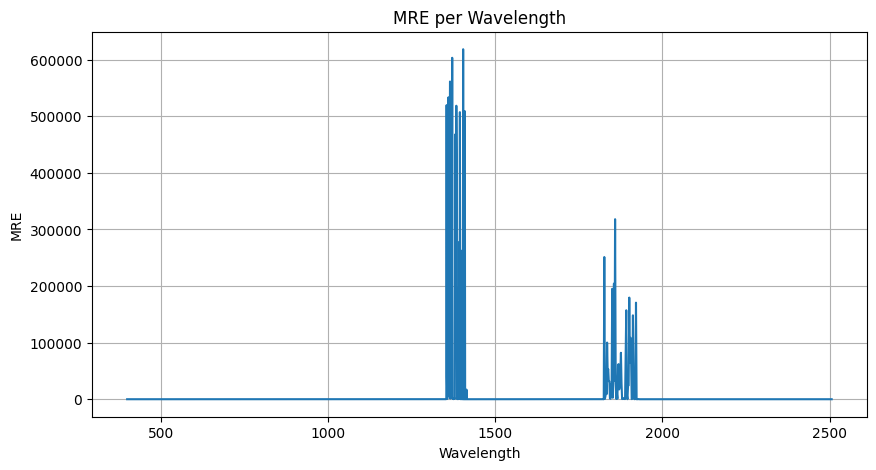

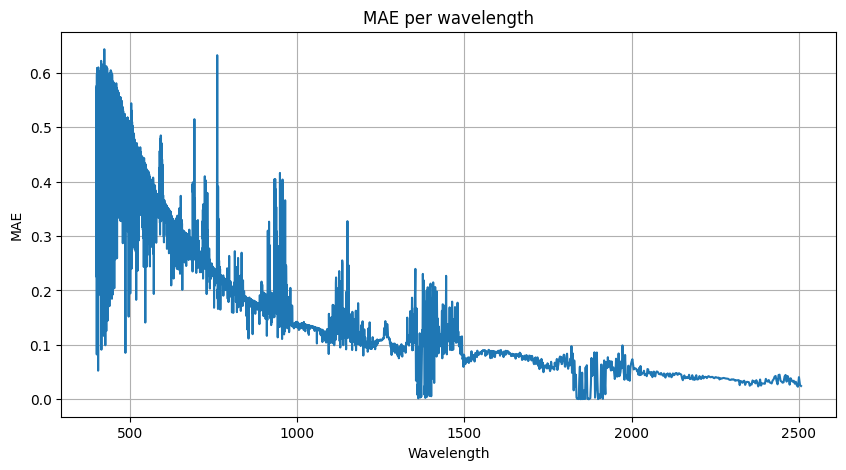

In [22]:
# MRE calculation
eps = 1e-8 # lower values of epsilon lead to very high MRE due to division by small numbers, higher values get more stable MRE estimates

# wavelengths to exclude from MRE calculation: 931-945 nm, 1100-1160 nm, 1300-1500 nm, 1750-1980 nm, and >2420 nm
mask = (
    ((wavelengths < 931) | (wavelengths > 945)) &
    ((wavelengths < 1100) | (wavelengths > 1160)) &
    ((wavelengths < 1300) | (wavelengths > 1500)) &
    ((wavelengths < 1750) | (wavelengths > 1980)) &
    (wavelengths < 2420)
)

mre = np.mean(
    np.abs(Y_val_pred[:, :, mask] - Y_val[:, :, mask]) /
    (np.abs(Y_val[:, :, mask]) + eps)
)
print("Validation MRE:", mre)

mre_per_func = np.mean(
    np.abs(Y_val_pred[:, :, mask] - Y_val[:, :, mask]) /
    (np.abs(Y_val[:, :, mask]) + eps),
    axis=(0, 2)
)
for i in range(Y_tr.shape[1]):
    print(f"Function {i+1} MRE: {mre_per_func[i]:.4f}")

mre_per_wvl = np.mean(
    np.abs(Y_val_pred - Y_val) /
    (np.abs(Y_val) + eps),
    axis=(0, 1)
)
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mre_per_wvl)
plt.xlabel("Wavelength")
plt.ylabel("MRE")
plt.title("MRE per Wavelength")
plt.grid()
plt.show()

mae_per_wvl = np.mean(
    np.abs(Y_val_pred - Y_val),
    axis=(0, 1)
)
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mae_per_wvl)
plt.xlabel("Wavelength")
plt.ylabel("MAE")
plt.title("MAE per wavelength")
plt.grid()
plt.show()

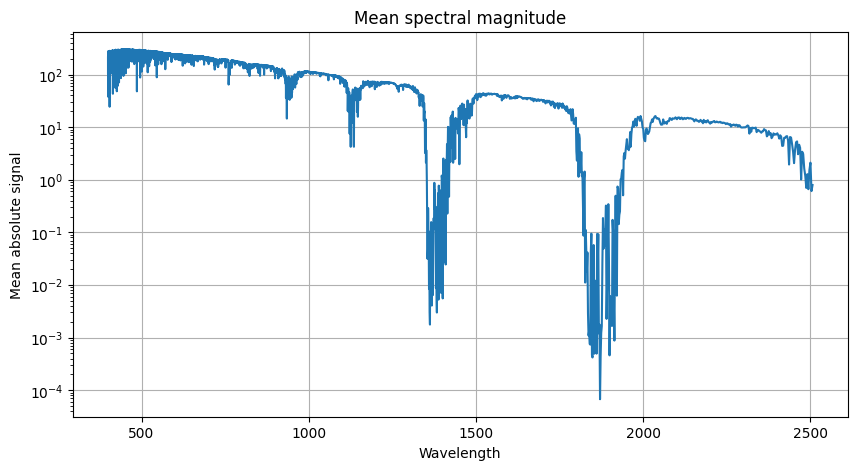

In [217]:
mean_spectrum = np.mean(np.abs(Y_val), axis=(0, 1))

plt.figure(figsize=(10,5))
plt.plot(wavelengths, mean_spectrum)
plt.yscale("log")
plt.xlabel("Wavelength")
plt.ylabel("Mean absolute signal")
plt.title("Mean spectral magnitude")
plt.grid()
plt.show()

Deep valleys at around 1400 and 1800-1900 nanometers, where the MRE spikes to high values.

MRE for sample 87: 0.0012
Function 1 MRE for sample 87: 0.0008
Function 2 MRE for sample 87: 0.0008
Function 3 MRE for sample 87: 0.0008
Function 4 MRE for sample 87: 0.0008
Function 5 MRE for sample 87: 0.0008
Function 6 MRE for sample 87: 0.0008


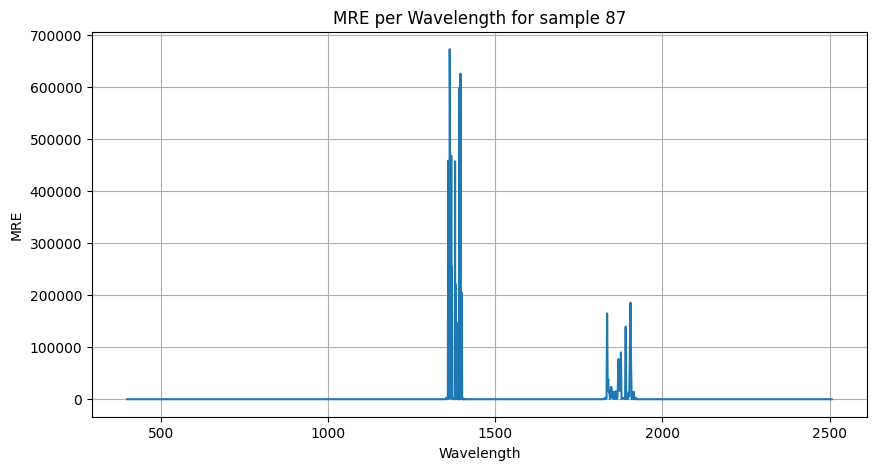

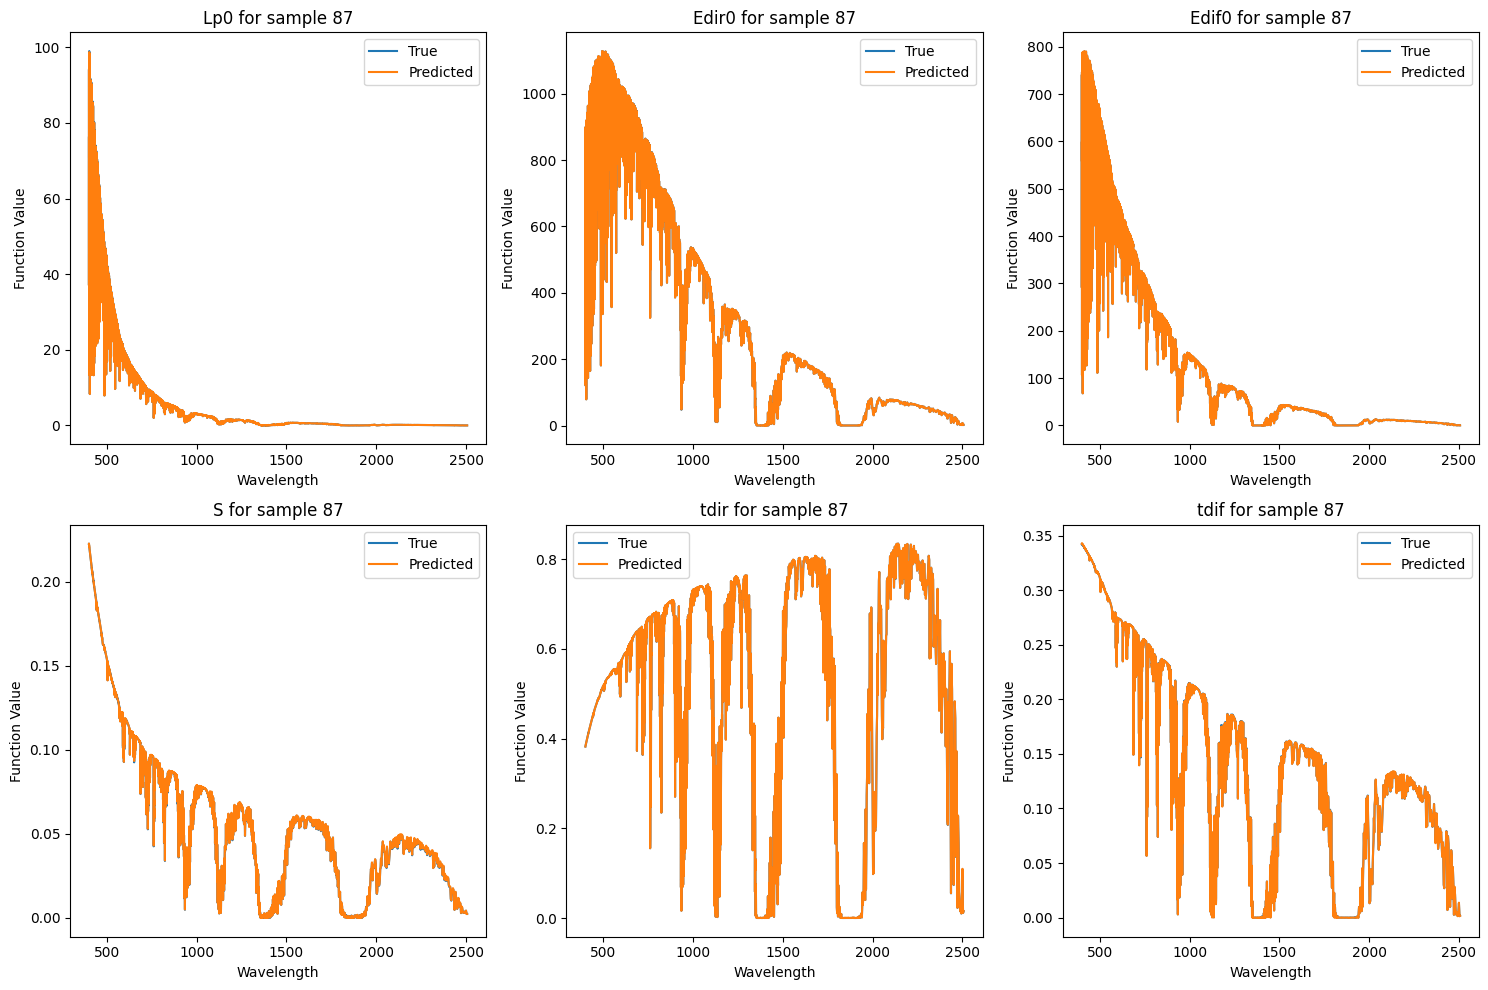

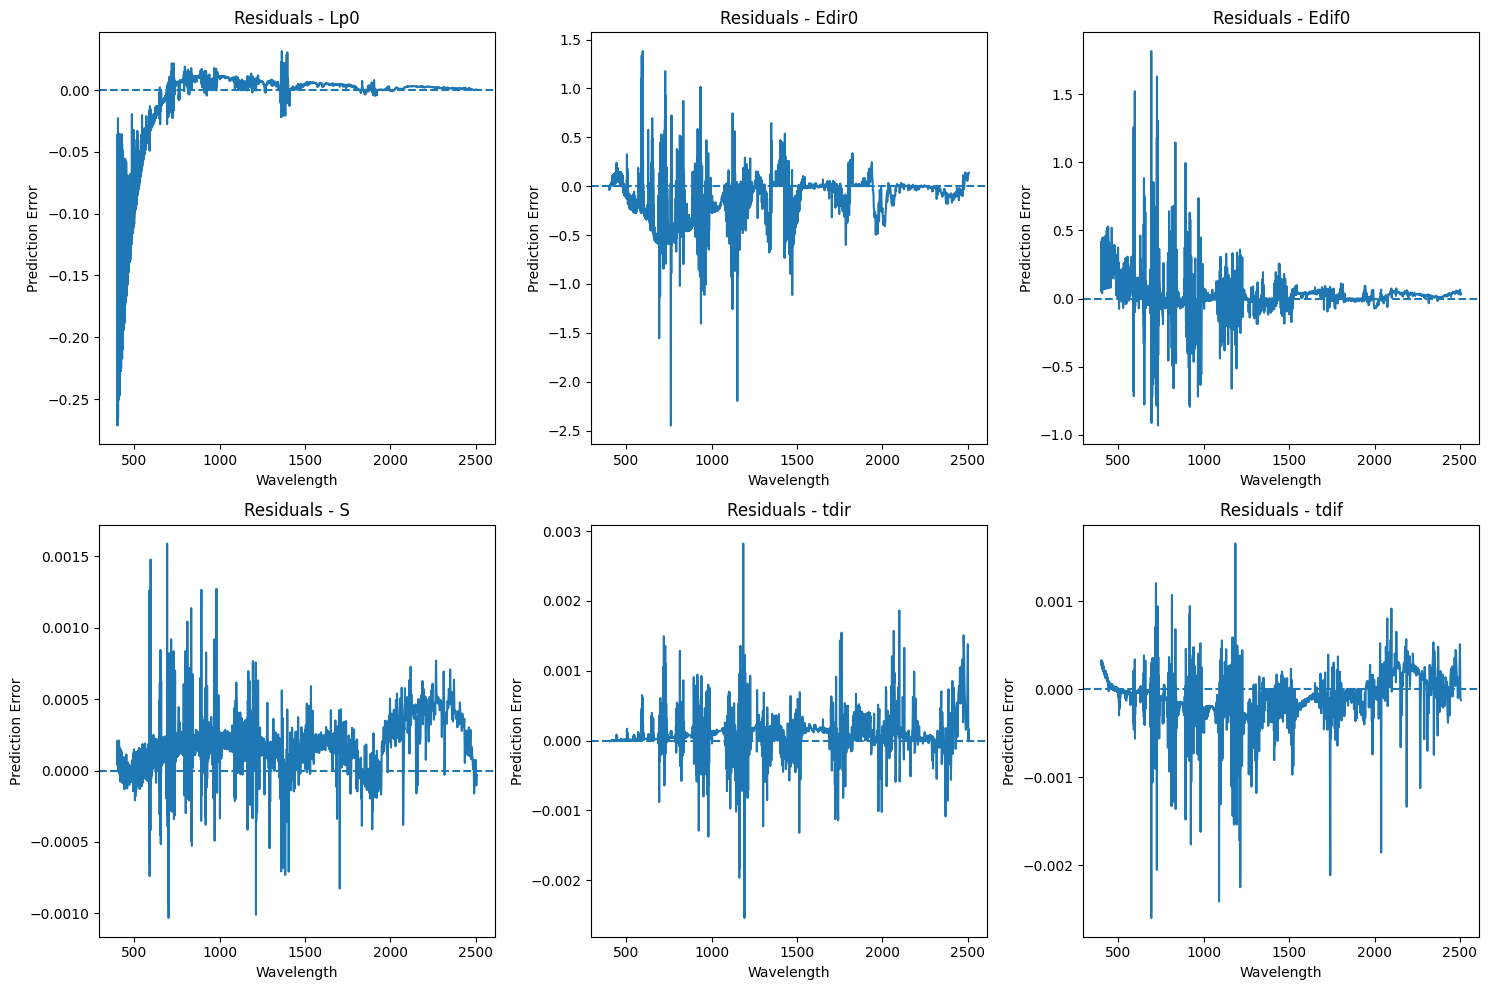

In [219]:
# predict functions for a random sample in validation set and calculate MRE for that sample
sample_idx = np.random.randint(Y_val.shape[0])

# calculate MRE for the selected sample with masking
mre_sample = np.mean(
    np.abs(Y_val_pred[sample_idx, :, mask] - Y_val[sample_idx, :, mask]) /
    (np.abs(Y_val[sample_idx, :, mask]) + eps)
)
print(f"MRE for sample {sample_idx}: {mre_sample:.4f}")

# calculate MRE for each function for the selected sample
mre_sample_per_func = np.mean(
    np.abs(Y_val_pred[sample_idx, :, mask] - Y_val[sample_idx, :, mask]) /
    (np.abs(Y_val[sample_idx, :, mask]) + eps),
    axis=1
)
for i in range(Y_val.shape[1]):
    print(f"Function {i+1} MRE for sample {sample_idx}: {mre_sample_per_func[i]:.4f}")

# calculate MRE for each wavelength for the selected sample
mre_sample_per_wvl = np.mean(
    np.abs(Y_val_pred[sample_idx] - Y_val[sample_idx]) /
    (np.abs(Y_val[sample_idx]) + eps),
    axis=0
)
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mre_sample_per_wvl)
plt.xlabel("Wavelength")
plt.ylabel("MRE")
plt.title(f"MRE per Wavelength for sample {sample_idx}")
plt.grid()
plt.show()

# visualize true vs predicted functions for the selected sample
plt.figure(figsize=(15, 10))
for i in range(Y_val.shape[1]):
    plt.subplot(2, 3, i+1)
    plt.plot(wavelengths, Y_val[sample_idx, i, :], label="True")
    plt.plot(wavelengths, Y_val_pred[sample_idx, i, :], label="Predicted")
    plt.title(f"{function_names[i]} for sample {sample_idx}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))

# residuals plot for the selected sample
for i in range(Y_val.shape[1]):
    plt.subplot(2, 3, i+1)

    residual = Y_val_pred[sample_idx, i] - Y_val[sample_idx, i]

    plt.plot(wavelengths, residual)
    plt.axhline(0, linestyle="--")

    plt.title(f"Residuals - {function_names[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()